In [1]:
import os
import json
import torch
import matplotlib.pyplot as plt
from posixpath import join
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from torch_geometric.loader import DataLoader
from fvcore.nn import FlopCountAnalysis, parameter_count_table

from EGAT import EGAT_model
import StrokeGraphDataset_class


RUN_DIRECTORY = "./checkpoints/40.0,2.0,23,19,2(5)/run_20260425_224854" 

BATCHES_DIRECTORY = "./batches/" + RUN_DIRECTORY["./checkpoints/".__len__():RUN_DIRECTORY.find("run_")-1]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Використовується пристрій: {device}")

Використовується пристрій: cuda


In [2]:
def read_config(path: str):
    with open(path, 'r') as f:
        return json.load(f)

configs = read_config(join(RUN_DIRECTORY, 'config.json'))
file_lists = read_config(join(RUN_DIRECTORY, 'file_list.json'))

test_files = file_lists.get("file test list:", [])
test_files_with_aug = list(test_files)
test_aug_only_files = []

for f in test_files:
    base = f.replace('_proc.pt', '')
    test_aug_only_files.extend([
        af for af in os.listdir(BATCHES_DIRECTORY) 
        if (af.startswith('aug') or af.startswith('sep')) 
        and af.endswith('_proc.pt') 
        and base in af
    ])

test_files_with_aug.extend(test_aug_only_files)

if configs["out_channels"] == 2:
    class_names = ["Non-Text", "Text"]
elif configs["out_channels"] == 5:
    class_names = ["Text", "Table", "Formula", "Diagram", "Other"]
else:
    class_names = [f"Class {i}" for i in range(configs["out_channels"])]

print(f"Кількість оригінальних тестових файлів: {len(test_files)}")
print(f"Кількість файлів з аугментацією (оригінали + ауг): {len(test_files_with_aug)}")

Кількість оригінальних тестових файлів: 95
Кількість файлів з аугментацією (оригінали + ауг): 769


In [3]:
batch_size = configs.get("batch_size", 4)

temp_dataset = StrokeGraphDataset_class.StrokeGraphDataset(BATCHES_DIRECTORY, test_files[:1])
temp_loader = DataLoader(temp_dataset, batch_size=1, shuffle=False)
sample_batch = next(iter(temp_loader))

model = EGAT_model(
    in_channels=sample_batch.x.size(1),
    hidden_channels=configs["hidden_channels"],
    out_channels=configs["out_channels"],
    edge_dim=sample_batch.edge_attr.size(1),
    heads=configs["heads"],
    num_hidden_layers=configs["hidden_layers"],
    dropout=configs["dropout"]
).to(device)

model_path = join(RUN_DIRECTORY, 'final_model.pt')
model.load_model(model_path, device)
model.eval()

print("Модель успішно завантажена та переведена в режим оцінки (eval)!")

def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Кількість параметрів у моделі: {total_params:,}")
    return total_params

def measure_flops(model, data):
    model.eval()
    inputs = (data.x, data.edge_index, data.edge_attr)
    
    flops = FlopCountAnalysis(model, inputs)
    
    flops.unsupported_ops_warnings(False)
    
    total_flops = flops.total()
    print(f"FLOPs для даного графа: {total_flops / 1e6:.2f} MegaFLOPs (MFLOPs)")
    
    return total_flops

count_parameters(model)

  missing keys: ['edge_bns.0.running_mean', 'edge_bns.0.running_var']
  unexpected keys: []
Модель успішно завантажена та переведена в режим оцінки (eval)!
Кількість параметрів у моделі: 329,061


329061

In [4]:
import torch.nn.functional as F
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score, cohen_kappa_score,
    matthews_corrcoef, hamming_loss, jaccard_score, log_loss, roc_auc_score
)

def evaluate_and_plot(model, dataloader, device, class_names, title_prefix="Test"):
    """Проганяє дані через модель, виводить розширений звіт метрик і малює Confusion Matrix inline."""
    all_preds = []
    all_labels = []
    all_probs = []
    
    once_ev_flops=True
    with torch.no_grad():
        for data in dataloader:
            data = data.to(device)
            if once_ev_flops:
                measure_flops(model, data)
                once_ev_flops = False
            out = model(data.x, data.edge_index, data.edge_attr)
            
            probs = F.softmax(out, dim=1)
            pred = out.argmax(dim=1)
            
            mask = ~data.is_virtual
            
            all_preds.extend(pred[mask].cpu().numpy())
            all_labels.extend(data.y[mask].cpu().numpy())
            all_probs.extend(probs[mask].cpu().numpy())

    print(f"\n{'='*60}")
    print(f"--- РОЗШИРЕНІ МЕТРИКИ: {title_prefix.upper()} ---")
    print(f"{'='*60}")

    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0)
    print("1. Звіт класифікації (Classification Report):\n", report)

    print("2. Додаткові метрики якості:")
    print(f"   - Accuracy (Загальна точність):          {accuracy_score(all_labels, all_preds):.4f}")
    print(f"   - Balanced Accuracy (Збалансована):      {balanced_accuracy_score(all_labels, all_preds):.4f}")
    print(f"   - Cohen's Kappa (Узгодженість):          {cohen_kappa_score(all_labels, all_preds):.4f}")
    print(f"   - Matthews Corrcoef (MCC)*:              {matthews_corrcoef(all_labels, all_preds):.4f}")
    print(f"   - Jaccard Score (Macro):                 {jaccard_score(all_labels, all_preds, average='macro'):.4f}")
    print(f"   - Hamming Loss (Частка помилок):         {hamming_loss(all_labels, all_preds):.4f}")
    
    print("\n3. Метрики на основі ймовірностей (Probabilities):")
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        print(f"   - ROC AUC (Macro OVR):                   {auc:.4f}")
    except Exception as e:
        print(f"   - ROC AUC: Неможливо обчислити ({e})")
        
    try:
        ll = log_loss(all_labels, all_probs)
        print(f"   - Log Loss (Крос-ентропія):              {ll:.4f}")
    except Exception as e:
        print(f"   - Log Loss: Неможливо обчислити ({e})")

    print("\n4. Confusion Matrix (Матриця помилок):")
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
    
    plt.title(f'Confusion Matrix ({title_prefix})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    #* MCC (Matthews Correlation Coefficient) вважається найкращою метрикою для незбалансованих класів (від -1 до +1).

=== Запуск тестування на оригінальних файлах ===
FLOPs для даного графа: 4213.22 MegaFLOPs (MFLOPs)

--- РОЗШИРЕНІ МЕТРИКИ: ORIGINAL FILES ---
1. Звіт класифікації (Classification Report):
               precision    recall  f1-score   support

        Text     0.9886    0.9732    0.9809     26837
       Table     0.8675    0.7397    0.7985       292
     Formula     0.8901    0.8940    0.8920      1585
     Diagram     0.8687    0.9496    0.9074      4698
       Other     0.6742    0.6834    0.6788      1175

    accuracy                         0.9546     34587
   macro avg     0.8578    0.8480    0.8515     34587
weighted avg     0.9561    0.9546    0.9550     34587

2. Додаткові метрики якості:
   - Accuracy (Загальна точність):          0.9546
   - Balanced Accuracy (Збалансована):      0.8480
   - Cohen's Kappa (Узгодженість):          0.8816
   - Matthews Corrcoef (MCC)*:              0.8822
   - Jaccard Score (Macro):                 0.7553
   - Hamming Loss (Частка помилок):  

c:\Users\ivan\.conda\envs\Diploma\Lib\site-packages\sklearn\metrics\_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


   - Log Loss (Крос-ентропія):              0.1769

4. Confusion Matrix (Матриця помилок):


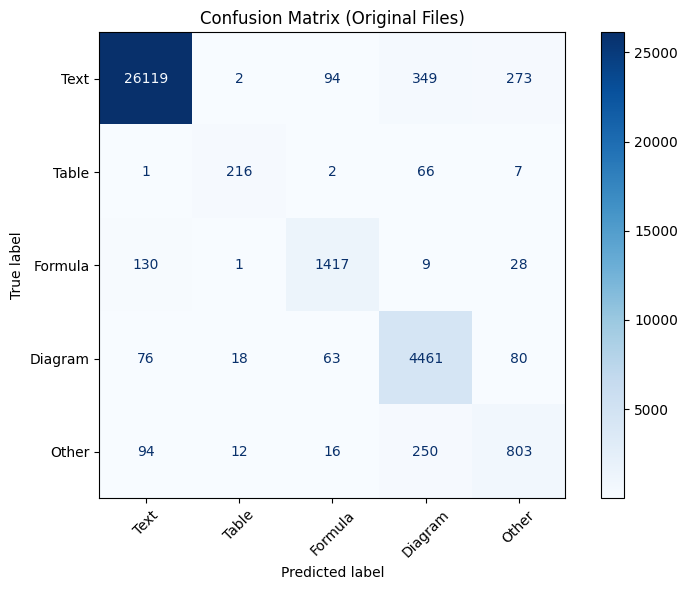

In [5]:
print("=== Запуск тестування на оригінальних файлах ===")
test_dataset = StrokeGraphDataset_class.StrokeGraphDataset(BATCHES_DIRECTORY, test_files)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

evaluate_and_plot(model, test_loader, device, class_names, title_prefix="Original Files")

=== Запуск тестування на файлах з аугментацією ===
FLOPs для даного графа: 4213.22 MegaFLOPs (MFLOPs)

--- РОЗШИРЕНІ МЕТРИКИ: WITH AUGMENTATION ---
1. Звіт класифікації (Classification Report):
               precision    recall  f1-score   support

        Text     0.9745    0.9625    0.9685    101511
       Table     0.8193    0.7422    0.7789      1668
     Formula     0.8892    0.8841    0.8866      5408
     Diagram     0.8311    0.9580    0.8901     23767
       Other     0.5900    0.4201    0.4908      7614

    accuracy                         0.9266    139968
   macro avg     0.8208    0.7934    0.8030    139968
weighted avg     0.9241    0.9266    0.9237    139968

2. Додаткові метрики якості:
   - Accuracy (Загальна точність):          0.9266
   - Balanced Accuracy (Збалансована):      0.7934
   - Cohen's Kappa (Узгодженість):          0.8345
   - Matthews Corrcoef (MCC)*:              0.8354
   - Jaccard Score (Macro):                 0.7000
   - Hamming Loss (Частка помило

c:\Users\ivan\.conda\envs\Diploma\Lib\site-packages\sklearn\metrics\_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


   - Log Loss (Крос-ентропія):              0.3040

4. Confusion Matrix (Матриця помилок):


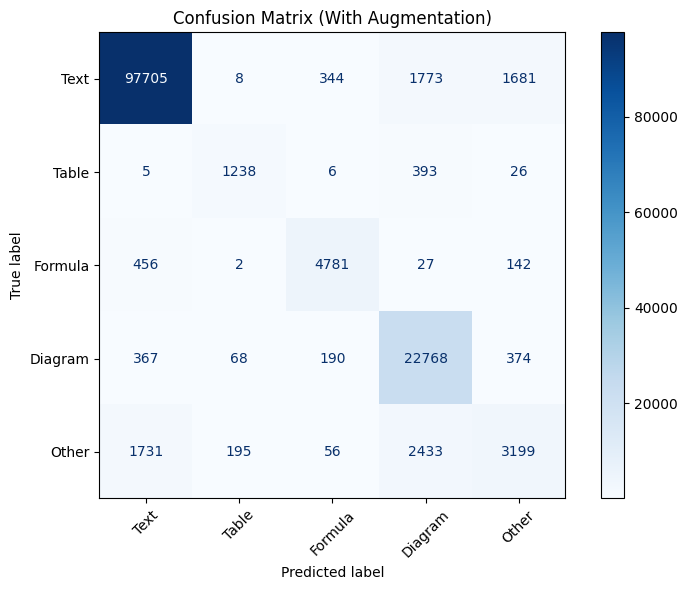

In [6]:
if test_aug_only_files:
    print("=== Запуск тестування на файлах з аугментацією ===")
    test_aug_dataset = StrokeGraphDataset_class.StrokeGraphDataset(BATCHES_DIRECTORY, test_files_with_aug)
    test_aug_loader = DataLoader(test_aug_dataset, batch_size=batch_size, shuffle=False)

    evaluate_and_plot(model, test_aug_loader, device, class_names, title_prefix="With Augmentation")
else:
    print("Аугментовані файли не знайдені у директорії батчів. Цей крок пропущено.")
    

Знайдені колонки у файлі: ['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'lr', 'time']
--- ОЦІНКА ВОЛАТИЛЬНОСТІ: Train Loss ---
Середній стрибок між епохами (Mean Abs Diff): 0.010481
Максимальний стрибок між епохами:             0.197734
Коеф. варіації (CV) на останніх 10 епохах:   0.0184 (менше - стабільніше)
--------------------------------------------------


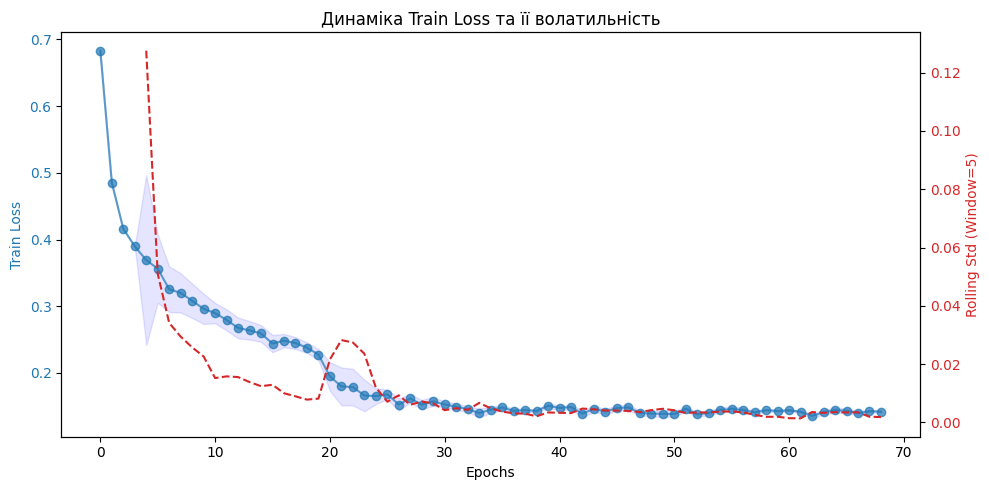

--- ОЦІНКА ВОЛАТИЛЬНОСТІ: Validation Loss ---
Середній стрибок між епохами (Mean Abs Diff): 0.021452
Максимальний стрибок між епохами:             0.104155
Коеф. варіації (CV) на останніх 10 епохах:   0.0453 (менше - стабільніше)
--------------------------------------------------


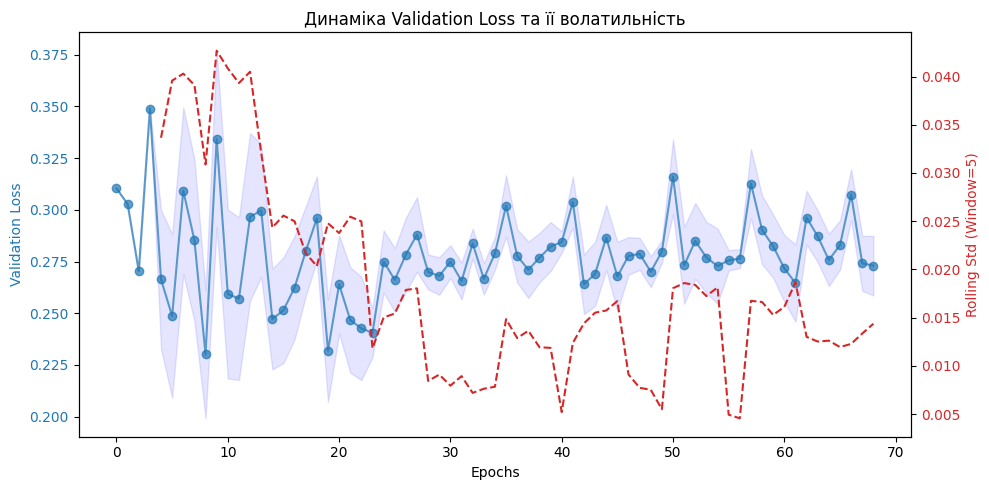

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from posixpath import join
import json

def plot_and_evaluate_volatility(loss_list, metric_name="Train Loss", window_size=5):
    """
    Аналізує та будує графік волатильності для переданого списку значень (loss або accuracy).
    """
    if len(loss_list) < window_size:
        print("Недостатньо епох для розрахунку ковзної волатильності.")
        return

    loss_series = pd.Series(loss_list)
    
    # 1. Розрахунок метрик волатильності
    # Ковзне стандартне відхилення
    rolling_std = loss_series.rolling(window=window_size).std()
    
    # Абсолютна зміна між сусідніми епохами
    epoch_diffs = loss_series.diff().abs()
    mean_epoch_diff = epoch_diffs.mean()
    
    # Коефіцієнт варіації для останніх 10 епох (або менше, якщо епох мало)
    last_n = min(10, len(loss_list))
    tail_losses = loss_series.tail(last_n)
    cv_last_n = tail_losses.std() / tail_losses.mean() if tail_losses.mean() != 0 else 0

    print(f"--- ОЦІНКА ВОЛАТИЛЬНОСТІ: {metric_name} ---")
    print(f"Середній стрибок між епохами (Mean Abs Diff): {mean_epoch_diff:.6f}")
    print(f"Максимальний стрибок між епохами:             {epoch_diffs.max():.6f}")
    print(f"Коеф. варіації (CV) на останніх {last_n} епохах:   {cv_last_n:.4f} (менше - стабільніше)")
    print("-" * 50)

    # 2. Побудова графіків
    fig, ax1 = plt.subplots(figsize=(10, 5))

    color = 'tab:blue'
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel(metric_name, color=color)
    ax1.plot(loss_series, color=color, marker='o', label=metric_name, alpha=0.7)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  # Створюємо другу вісь Y для волатильності
    color_std = 'tab:red'
    ax2.set_ylabel(f'Rolling Std (Window={window_size})', color=color_std)
    ax2.plot(rolling_std, color=color_std, linestyle='--', label='Rolling Std (Volatility)')
    ax2.tick_params(axis='y', labelcolor=color_std)

    # Заповнюємо область для візуалізації розкиду (волатильності)
    ax1.fill_between(loss_series.index, 
                     loss_series - rolling_std.fillna(0), 
                     loss_series + rolling_std.fillna(0), 
                     color='blue', alpha=0.1)

    plt.title(f'Динаміка {metric_name} та її волатильність')
    fig.tight_layout()
    plt.show()

#RUN_DIRECTORY = "C:\\Users\\ivan\\Desktop\\GRU\\run_20260425_224854"
csv_path = join(RUN_DIRECTORY, 'metrics.csv') 

try:
    df_metrics = pd.read_csv(csv_path)
    
    print("Знайдені колонки у файлі:", df_metrics.columns.tolist())
    
    if 'train_loss' in df_metrics.columns:
        plot_and_evaluate_volatility(df_metrics['train_loss'].dropna().tolist(), metric_name="Train Loss")
        
    if 'val_loss' in df_metrics.columns:
        plot_and_evaluate_volatility(df_metrics['val_loss'].dropna().tolist(), metric_name="Validation Loss")
        
    # Якщо колонка називається просто 'loss'
    elif 'loss' in df_metrics.columns:
        plot_and_evaluate_volatility(df_metrics['loss'].dropna().tolist(), metric_name="Training Loss")

except FileNotFoundError:
    print(f"Помилка: Файл {csv_path} не знайдено. Перевір шлях до файлу.")
except pd.errors.EmptyDataError:
    print("Помилка: Файл metrics.csv порожній.")